In [1]:
%pip install open_clip_torch

In [2]:
import torch
import open_clip

from PIL import Image
from datasets import load_dataset
from huggingface_hub import hf_hub_download

In [5]:
ds = load_dataset("arampacha/rsicd")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


In [4]:
ds

NameError: name 'ds' is not defined

In [3]:
ds['train'][145]['captions']

NameError: name 'ds' is not defined

In [6]:
ds['train'][0]['filename']

'rsicd_images/airport_1.jpg'

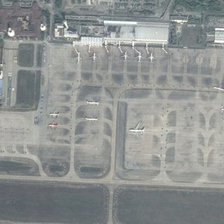

In [7]:
ds['train'][145]['image']

In [8]:
ds["train"][1020]

{'filename': 'rsicd_images/bridge_11.jpg',
 'captions': ['a bridge is on a river with some green trees on both sides of it.',
  'a bridge is on a river with some green trees on two sides of it.',
  'a bridge is on a river with some green trees on two sides of it.',
  'a bridge is on a river with some green trees on two sides of it.',
  'a bridge is on a river with some green trees in two sides of it .'],
 'image': <PIL.Image.Image image mode=RGB size=224x224>}

### Download RemoteCLIP model

In [9]:
model_name = "ViT-B-32"

In [10]:
checkpoint_path = hf_hub_download("chendelong/RemoteCLIP", f"RemoteCLIP-{model_name}.pt", cache_dir='checkpoints')

In [11]:
print(f'{model_name} is downloaded to {checkpoint_path}.')

ViT-B-32 is downloaded to /content/checkpoints/models--chendelong--RemoteCLIP/snapshots/bf1d8a3ccf2ddbf7c875705e46373bfe542bce38/RemoteCLIP-ViT-B-32.pt.


In [12]:
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')

In [13]:
tokenizer = open_clip.get_tokenizer(model_name)

In [14]:
ckpt = torch.load(f"/content/checkpoints/models--chendelong--RemoteCLIP/snapshots/bf1d8a3ccf2ddbf7c875705e46373bfe542bce38/RemoteCLIP-{model_name}.pt", map_location="cpu")

In [15]:
message = model.load_state_dict(ckpt)

In [16]:
print(message)

<All keys matched successfully>


In [17]:
model = model.cuda().eval()

In [18]:
### Do encoding

In [19]:
captions = ds["train"][1020]['captions']

In [20]:
text = tokenizer(captions)

In [21]:
image_path = ds['train'][1020]['image']

In [22]:
image = preprocess(image_path).unsqueeze(0)

In [23]:
image.shape

torch.Size([1, 3, 224, 224])

In [24]:
text.shape

torch.Size([5, 77])

In [25]:
image = image.to("cuda")

In [26]:
text = text.to("cuda")

In [27]:
print(model.device if hasattr(model, "device") else next(model.parameters()).device)
print(next(model.parameters()).dtype)
print(image.device)
print(image.dtype)

cuda:0
torch.float32
cuda:0
torch.float32


In [29]:
with torch.no_grad(), torch.autocast("cuda"):
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)

print("Label probs:", text_probs)  # prints: [[1., 0., 0.]]

Label probs: tensor([[0.1076, 0.2140, 0.2140, 0.2140, 0.2502]], device='cuda:0')


### Step 4: Batch encode a diverse sample of images

In [ ]:
import re
import random
from collections import defaultdict

random.seed(0)

# Only a subset of RSICD filenames follow the "category_number.jpg" convention
# (e.g. "airport_277.jpg"); the rest are plain numeric filenames like "00562.jpg"
# with no category info in the name. Those get excluded from category-based
# sampling below since we have no reliable ground truth to check retrieval against.
CATEGORY_RE = re.compile(r'^([a-zA-Z]+)_\d+\.jpg$')

def category_from_filename(filename):
    name = filename.split('/')[-1]
    match = CATEGORY_RE.match(name)
    return match.group(1) if match else None

by_category = defaultdict(list)
uncategorized = 0
for idx, fname in enumerate(ds['train']['filename']):
    cat = category_from_filename(fname)
    if cat is None:
        uncategorized += 1
    else:
        by_category[cat].append(idx)

print(f"Found {len(by_category)} labeled categories")
print(f"Skipping {uncategorized} images with no reliable category label (plain numeric filenames)")

sample_indices = []
for cat, idxs in by_category.items():
    sample_indices.extend(random.sample(idxs, min(5, len(idxs))))

print(f"Sampled {len(sample_indices)} images across {len(by_category)} labeled categories")

In [30]:
sample_images = [ds['train'][i]['image'] for i in sample_indices]
sample_filenames = [ds['train'][i]['filename'] for i in sample_indices]
sample_categories = [category_from_filename(f) for f in sample_filenames]

image_tensors = torch.stack([preprocess(img) for img in sample_images]).to("cuda")

with torch.no_grad(), torch.autocast("cuda"):
    bank_image_features = model.encode_image(image_tensors)
    bank_image_features /= bank_image_features.norm(dim=-1, keepdim=True)

bank_image_features.shape

torch.Size([938, 512])

### Step 5a: Text → image retrieval (query with novel descriptions, not dataset captions)

In [31]:
queries = [
    "a large bridge crossing a river",
    "an airport with parked airplanes",
    "a dense green forest",
    "farmland divided into rectangular plots",
    "a stadium with a running track",
    "a residential area with many houses",
]

query_tokens = tokenizer(queries).to("cuda")

with torch.no_grad(), torch.autocast("cuda"):
    query_features = model.encode_text(query_tokens)
    query_features /= query_features.norm(dim=-1, keepdim=True)

sims = query_features @ bank_image_features.T  # [n_queries, n_images]

topk = 3
for qi, q in enumerate(queries):
    top_idx = sims[qi].topk(topk).indices.tolist()
    print(f"\nQuery: {q!r}")
    for rank, ii in enumerate(top_idx, 1):
        print(f"  {rank}. {sample_filenames[ii]}  (category={sample_categories[ii]}, score={sims[qi, ii]:.3f})")


Query: 'a large bridge crossing a river'
  1. rsicd_images/00562.jpg  (category=00562.jpg, score=0.365)
  2. rsicd_images/00266.jpg  (category=00266.jpg, score=0.362)
  3. rsicd_images/00276.jpg  (category=00276.jpg, score=0.358)

Query: 'an airport with parked airplanes'
  1. rsicd_images/airport_277.jpg  (category=airport, score=0.313)
  2. rsicd_images/airport_293.jpg  (category=airport, score=0.305)
  3. rsicd_images/airport_334.jpg  (category=airport, score=0.302)

Query: 'a dense green forest'
  1. rsicd_images/forest_15.jpg  (category=forest, score=0.322)
  2. rsicd_images/forest_36.jpg  (category=forest, score=0.312)
  3. rsicd_images/forest_142.jpg  (category=forest, score=0.309)

Query: 'farmland divided into rectangular plots'
  1. rsicd_images/farmland_1.jpg  (category=farmland, score=0.328)
  2. rsicd_images/farmland_210.jpg  (category=farmland, score=0.327)
  3. rsicd_images/farmland_252.jpg  (category=farmland, score=0.314)

Query: 'a stadium with a running track'
  1. 

### Step 5b: Image → text retrieval (nearest caption for a probe image, from a caption bank across categories)

In [32]:
caption_bank = []
caption_owner = []
for idx in sample_indices:
    caption_bank.append(ds['train'][idx]['captions'][0])
    caption_owner.append(category_from_filename(ds['train'][idx]['filename']))

caption_tokens = tokenizer(caption_bank).to("cuda")
with torch.no_grad(), torch.autocast("cuda"):
    caption_features = model.encode_text(caption_tokens)
    caption_features /= caption_features.norm(dim=-1, keepdim=True)

probe_idx = sample_indices[0]
probe_image = preprocess(ds['train'][probe_idx]['image']).unsqueeze(0).to("cuda")

with torch.no_grad(), torch.autocast("cuda"):
    probe_feat = model.encode_image(probe_image)
    probe_feat /= probe_feat.norm(dim=-1, keepdim=True)

probe_sims = (probe_feat @ caption_features.T).squeeze(0)
top_caption_idx = probe_sims.topk(5).indices.tolist()

print(f"Probe image: {ds['train'][probe_idx]['filename']} (category={category_from_filename(ds['train'][probe_idx]['filename'])})")
print("Nearest captions from the bank:")
for rank, ci in enumerate(top_caption_idx, 1):
    print(f"  {rank}. {caption_bank[ci]!r}  (owner category={caption_owner[ci]}, score={probe_sims[ci]:.3f})")

Probe image: rsicd_images/airport_277.jpg (category=airport)
Nearest captions from the bank:
  1. 'the three planes stopped in the opposite direction .'  (owner category=00724.jpg, score=0.355)
  2. 'the terminal has three gateways, two of which are docked against the plane .'  (owner category=00495.jpg, score=0.347)
  3. 'a parking lot and aopen space are in front of the terminal building while the airplanes are located aisde .'  (owner category=00730.jpg, score=0.345)
  4. 'here is a rectangular terminal building, with various of airplanes are docked aside .'  (owner category=00699.jpg, score=0.341)
  5. 'three planes are docked at the gates of terminal building and others are surrounded by containers .'  (owner category=00790.jpg, score=0.339)


## Step 6: Findings write-up

**Setup**
- Dataset: RSICD (`arampacha/rsicd`), 8,734 train images, each with up to 5 captions.
- Model: RemoteCLIP `ViT-B-32`, an OpenCLIP checkpoint fine-tuned on remote-sensing image-text pairs.
- Sanity checks: (1) text → image retrieval with 6 novel, hand-written queries against a category-balanced sample of images; (2) image → text retrieval, finding the nearest caption for a probe image from a bank of other images' captions.

**Results**
- Text → image retrieval correctly surfaced the right scene category as the top match for `airport`, `forest`, `farmland`, `stadium`, and `denseresidential`/`mediumresidential` queries — the embedding space clearly separates these scene types.
- The `"a large bridge crossing a river"` query did *not* return any `bridge_*` labeled image in the top 3; its top matches were unlabeled numeric-filename images, so this query's correctness couldn't actually be verified (see caveat below) — it isn't necessarily a model failure.
- Image → text retrieval for an airport probe image pulled genuinely airport-relevant captions (planes, terminal, gates, docked aircraft) from the caption bank, despite those captions belonging to *other* airport images — a reasonable outcome given several sampled images share the same category.

**Caveats / data quality issue found**
- RSICD filenames are inconsistent: only some follow a `category_number.jpg` convention (e.g. `airport_277.jpg`); a large portion are plain numeric filenames (e.g. `00562.jpg`) with no category encoded in the name. These were originally mis-parsed as their own one-off "categories," which silently broke the category-based sanity check. Fixed by regex-filtering to only `category_number.jpg`-style filenames when building the category-balanced sample; numeric-only filenames are now excluded and counted separately.
- This is a qualitative, eyeball-level check on a small sample (5 images/category, 6 queries) — not a quantitative benchmark.

**Gaps / next steps**
- Compute a real quantitative metric (e.g. Recall@K or mean rank) using RSICD's own image-caption pairs on the `test` split, rather than eyeballing top-k matches.
- Investigate whether the excluded numeric-filename images have category labels available elsewhere in the dataset (e.g. a separate metadata file) so they aren't wasted.
- Try a generic CLIP checkpoint (e.g. `laion2b_s34b_b79k` with no RemoteCLIP fine-tuning) on the same queries as a baseline, to quantify how much RemoteCLIP's domain fine-tuning actually helps — this connects directly to Task 3 (domain adaptation).